# 4.4 — Seizure-related changes in directed connectivity
### Ictal vs. non-ictal analysis of Granger-causal (GC) connectivity — reproducible notebook

This notebook reproduces every table and figure in Section 4.4 from a single input file,
`ICTAL_VS_NONICTAL_ALLREC_SUMMARY.csv` (one row per patient × feature, 24 × 1530), plus the
mRMR selection log `LONG_SELECTED_FEATURES.csv` for the band/channel correspondence at the end.

**Definitions used here (all-records):** for each patient, *ictal* = all seizure windows;
*non-ictal* = every other window, pooling the interictal background of the seizure recordings
with all windows of the seizure-free recordings.

**Metrics.** For each of the 1,530 GC features and each patient we use two class-separation
measures: **AUC** (the normalised Mann–Whitney U statistic; a *feature-level* separation measure,
not a classifier score) and **Cohen's d** (standardised mean difference). Both are dimensionless
and scale-free, so they can be averaged across features, bands and patients without normalisation.
Everything is summarised *within* each patient first, then averaged across patients, so every
patient counts equally regardless of recording length.

## 0 · Setup and configuration
Edit the two paths if your files live elsewhere.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# ---- input files ----
SUMMARY_FILE  = "../RESULTS/ICTAL_VS_NONICTAL_ALLREC_SUMMARY.csv"   # ictal-vs-nonictal per-feature summary
SELECTED_FILE = "../RESULTS/LONG_SELECTED_FEATURES.csv"             # mRMR selection log (for 4.4.5 only)

# ---- constants ----
BANDS  = ["delta", "theta", "alpha", "beta", "gamma"]    # canonical index order
N_CHAN = 18
STRONG_D = 0.8          # |Cohen's d| threshold for "strongly changed"
STRONG_AUC = 0.2        # |AUC-0.5| threshold for "strongly changed"
BCOL = {"delta":"#3b4cc0","theta":"#7b9ff9","alpha":"#9aa0a6","beta":"#f4a15c","gamma":"#b40426"}

## 1 · Feature map: index → band / source / target

Each of the 1,530 features is a directed edge `band_source_target`. The index order is five
band blocks of 306 (= 18 × 17 directed pairs), and within a band the pairs run
`(source-1)*17 + target`, skipping self-loops. Rebuilding this map lets us attach a band and a
pair of channels to every feature.

In [4]:
def feature_map():
    rows, idx = [], 0
    for b in BANDS:
        for s in range(1, N_CHAN+1):
            for t in range(1, N_CHAN+1):
                if s == t:
                    continue
                rows.append((idx, b, s, t)); idx += 1
    return pd.DataFrame(rows, columns=["feature_index","band","src","tgt"])

fmap = feature_map()
assert len(fmap) == 1530
fmap.head()

,feature_index,band,src,tgt
0,0,delta,1,2
1,1,delta,1,3
2,2,delta,1,4
3,3,delta,1,5
4,4,delta,1,6


## 2 · Load the summary and derive effect columns

`auc > 0.5` means the feature is **larger** during seizures; `auc < 0.5` means smaller.
We add:
- `dev = |auc - 0.5|` — a signless *magnitude* of ictal change, comparable across features;
- `dir  = sign(auc - 0.5)` — whether the feature increases (+1) or decreases (−1) in seizures.

In [5]:
d = pd.read_csv(SUMMARY_FILE).merge(fmap, on="feature_index")
d["dev"] = (d.auc - 0.5).abs()
d["dir"] = np.sign(d.auc - 0.5)

print("patients:", d.patient.nunique(), "| features/patient:", d.groupby('patient').size().unique())
d.head()

patients: 24 | features/patient: [1530]


,patient,feature_index,n_ictal,n_interictal,mean_ictal,mean_interictal,auc,abs_auc,cohen_d,band,src,tgt,dev,dir
0,chb01,0,180,58085,0.010,0.007,0.524,0.524,0.250,delta,1,2,0.024,1.000
1,chb01,1,180,58085,0.009,0.007,0.524,0.524,0.121,delta,1,3,0.024,1.000
2,chb01,2,180,58085,0.008,0.007,0.486,0.514,0.130,delta,1,4,0.014,-1.000
3,chb01,3,180,58085,0.010,0.008,0.526,0.526,0.184,delta,1,5,0.026,1.000
4,chb01,4,180,58085,0.007,0.007,0.499,0.501,0.011,delta,1,6,0.001,-1.000


### Window counts (why class imbalance matters)

Seizures are rare, so the non-ictal class is enormous relative to the ictal class. Both AUC and
Cohen's d are robust to this imbalance, but the counts are worth reporting.

In [6]:
w = d.groupby("patient")[["n_ictal","n_interictal"]].first()
w["ictal_frac"] = w.n_ictal / (w.n_ictal + w.n_interictal)
print(f"TOTAL ictal windows:     {w.n_ictal.sum():,}")
print(f"TOTAL non-ictal windows: {w.n_interictal.sum():,}")
print(f"ictal fraction per patient: {w.ictal_frac.min():.4f} – {w.ictal_frac.max():.4f}")
w

TOTAL ictal windows:     4,469
TOTAL non-ictal windows: 1,737,643
ictal fraction per patient: 0.0005 – 0.0127


,n_ictal,n_interictal,ictal_frac
patient,,,
chb01,180,58085,0.003
chb02,70,66445,0.001
chb03,163,69326,0.002
chb04,152,294240,0.001
chb05,224,72144,0.003
chb06,64,115583,0.001
chb07,150,124496,0.001
chb08,367,29825,0.012
chb09,111,119877,0.001


## 4.4.2 · Frequency-specific ictal changes

For each patient we average the effect within each band, then average those per-patient band
summaries across the 24 patients (equal patient weight). We report:
- `mean_dev` — mean |AUC−0.5| (change magnitude);
- `mean_d` — mean Cohen's d (signed; negative = connectivity **decreases** in seizures);
- `% increasing` — share of features with AUC > 0.5;
- `% strong` — share passing |AUC−0.5| ≥ 0.2.

In [7]:
recs = []
for pid, g in d.groupby("patient"):
    for b in BANDS:
        s = g[g.band == b]
        recs.append(dict(patient=pid, band=b,
                         dev=s.dev.mean(), d=s.cohen_d.mean(),
                         absd=s.cohen_d.abs().mean(),
                         pct_incr=(s.dir > 0).mean()*100,
                         pct_strong_auc=(s.dev >= STRONG_AUC).mean()*100,
                         pct_strong_d=(s.cohen_d.abs() >= STRONG_D).mean()*100))
pp = pd.DataFrame(recs)
band_tbl = pp.groupby("band").agg(
    mean_dev=("dev","mean"), sd_dev=("dev","std"),
    mean_d=("d","mean"), mean_absd=("absd","mean"),
    pct_increasing=("pct_incr","mean"),
    pct_strong_auc=("pct_strong_auc","mean")).reindex(BANDS)
band_tbl.round(3)   # >>> Table 1

,mean_dev,sd_dev,mean_d,mean_absd,pct_increasing,pct_strong_auc
band,,,,,,
delta,0.060,0.024,-0.103,0.194,25.572,1.280
theta,0.065,0.025,-0.128,0.206,21.024,1.988
alpha,0.075,0.027,-0.166,0.236,15.074,3.023
beta,0.090,0.031,-0.232,0.285,11.601,6.223
gamma,0.101,0.032,-0.273,0.315,9.096,9.913


**Reading Table 1.** Change magnitude rises monotonically delta → gamma, and the fraction of
*increasing* features falls the same way. So seizures are dominated by a broad **reduction** of
directed connectivity that is strongest and most consistent in gamma.

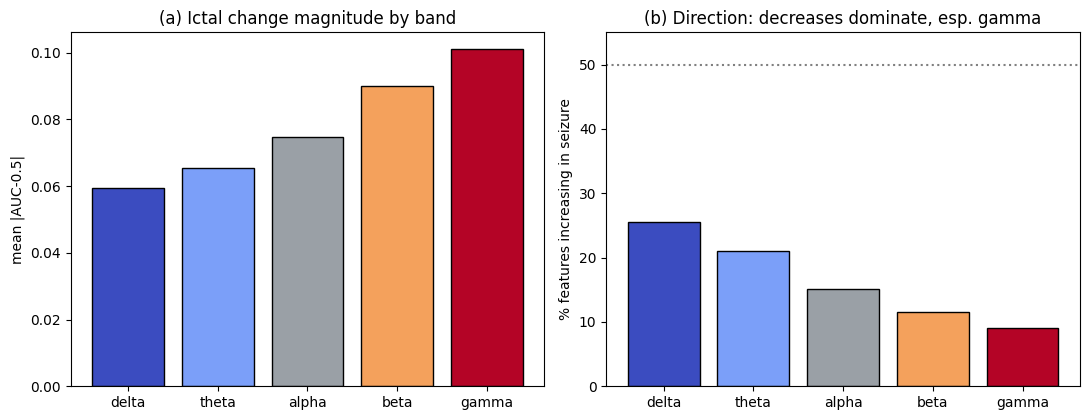

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].bar(BANDS, band_tbl.mean_dev, color=[BCOL[b] for b in BANDS], edgecolor="k")
ax[0].set_ylabel("mean |AUC-0.5|"); ax[0].set_title("(a) Ictal change magnitude by band")
ax[1].bar(BANDS, band_tbl.pct_increasing, color=[BCOL[b] for b in BANDS], edgecolor="k")
ax[1].axhline(50, ls=":", c="gray"); ax[1].set_ylim(0, 55)
ax[1].set_ylabel("% features increasing in seizure")
ax[1].set_title("(b) Direction: decreases dominate, esp. gamma")
plt.tight_layout(); plt.show()   # >>> Figure 1

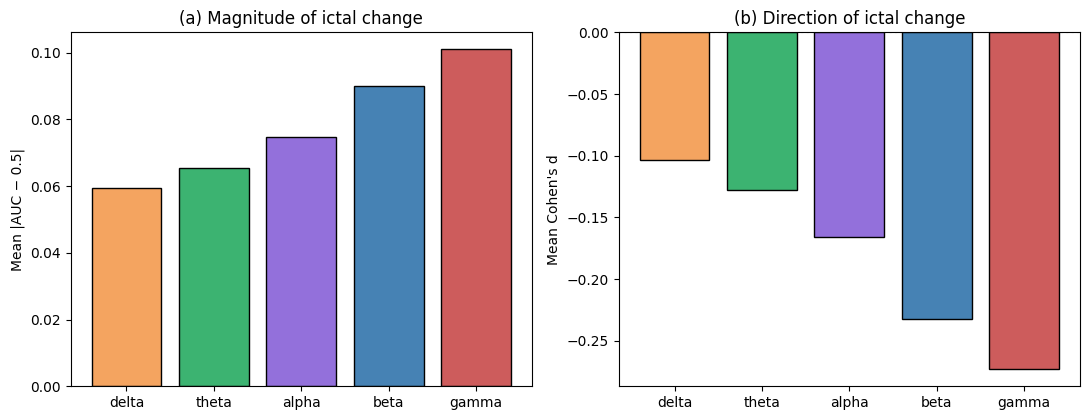

In [17]:
# Consistent colours by band
band_colors = {
    "delta": "sandybrown",
    "theta": "mediumseagreen",
    "alpha": "mediumpurple",
    "beta": "steelblue",
    "gamma": "indianred",
}

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))

# (a) Magnitude of ictal change
ax[0].bar(
    BANDS,
    band_tbl.mean_dev,
    color=[band_colors[b] for b in BANDS],
    edgecolor="k",
)
ax[0].set_ylabel("Mean |AUC − 0.5|")
ax[0].set_title("(a) Magnitude of ictal change")

# (b) Direction of ictal change
ax[1].bar(
    BANDS,
    band_tbl.mean_d,
    color=[band_colors[b] for b in BANDS],
    edgecolor="k",
)
ax[1].axhline(0, color="gray", linestyle=":")
ax[1].set_ylabel("Mean Cohen's d")
ax[1].set_title("(b) Direction of ictal change")

plt.tight_layout()
plt.show()

## 4.4.3 · Spatial distribution of ictal changes

Aggregating each edge's `dev` across bands and patients localises the change in the network.
We rank channels by the mean change of the edges on which they act as **source** and as
**target**, and list the individual edges that change most.

In [9]:
src_imp = d.groupby("src").dev.mean().sort_values(ascending=False)
tgt_imp = d.groupby("tgt").dev.mean().sort_values(ascending=False)
chan_tbl = pd.DataFrame({
    "source_channel": src_imp.index, "source_dev": src_imp.values,
    "target_channel": tgt_imp.index, "target_dev": tgt_imp.values,
}, index=range(1, N_CHAN+1))
chan_tbl.head(6).round(3)   # >>> Table 2 (top rows)

,source_channel,source_dev,target_channel,target_dev
1,17,0.109,13,0.091
2,18,0.108,12,0.089
3,11,0.083,11,0.089
4,7,0.079,5,0.087
5,12,0.078,9,0.085
6,10,0.077,7,0.083


In [23]:
edge = (d.groupby(["src","tgt"])
          .agg(dev=("dev","mean"), dirn=("dir","mean"), absd=("cohen_d", lambda x: x.abs().mean()))
          .reset_index())
edge["direction"] = np.where(edge.dirn > 0, "increase", "decrease")
strongest = edge.sort_values("dev", ascending=False).head(12)[["src","tgt","dev","absd","direction"]]
strongest.round(3)   # >>> Table 3

,src,tgt,dev,absd,direction
299,18,11,0.159,0.664,decrease
296,18,8,0.139,0.451,decrease
295,18,7,0.135,0.479,decrease
277,17,6,0.134,0.584,increase
300,18,12,0.133,0.425,decrease
281,17,10,0.132,0.483,increase
184,11,16,0.131,0.356,decrease
145,9,11,0.130,0.357,decrease
248,15,11,0.130,0.360,decrease
284,17,13,0.128,0.455,increase


**Reading Tables 2–3.** Two source hubs dominate: channels **17 and 18**. The directional
signature splits them — channel 18 is the source of the strongest *decreasing* edges
(18→11, 18→8, 18→7…), while channel 17 sources the strongest *increasing* edges (17→6, 17→10…).
Target-side change is more diffuse.

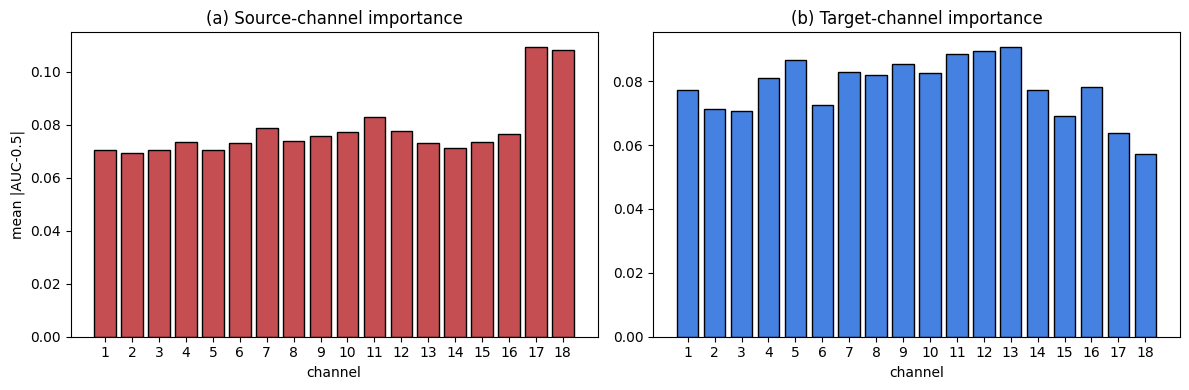

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(src_imp.sort_index().index, src_imp.sort_index().values, color="#C44E52", edgecolor="k")
ax[0].set_title("(a) Source-channel importance"); ax[0].set_xlabel("channel")
ax[0].set_ylabel("mean |AUC-0.5|"); ax[0].set_xticks(range(1, N_CHAN+1))
ax[1].bar(tgt_imp.sort_index().index, tgt_imp.sort_index().values, color="#4581E1", edgecolor="k")
ax[1].set_title("(b) Target-channel importance"); ax[1].set_xlabel("channel"); ax[1].set_xticks(range(1, N_CHAN+1))
plt.tight_layout(); plt.show()   # >>> Figure 2

## 4.4.4 · Patient-level variability

Population means hide large between-patient differences. We summarise each patient's overall
effect and its single most-separable feature, then show the per-patient × band picture as a
heatmap.

In [21]:
pat = d.groupby("patient").agg(
    mean_dev=("dev","mean"),
    max_auc=("auc", lambda x: (x-0.5).abs().max()+0.5)).sort_values("max_auc")
print(f"mean |AUC-0.5| per patient: {pat.mean_dev.min():.3f} – {pat.mean_dev.max():.3f}")
print(f"max ictal AUC per patient:  {pat.max_auc.min():.3f} ({pat.index[0]}) – "
      f"{pat.max_auc.max():.3f} ({pat.index[-1]}), median {pat.max_auc.median():.3f}")
pat.round(3)

mean |AUC-0.5| per patient: 0.033 – 0.138
max ictal AUC per patient:  0.679 (chb12) – 0.951 (chb01), median 0.849


,mean_dev,max_auc
patient,,
chb12,0.033,0.679
chb13,0.035,0.740
chb15,0.058,0.745
chb08,0.039,0.749
chb06,0.074,0.759
chb07,0.082,0.782
chb16,0.083,0.789
chb04,0.104,0.793
chb14,0.072,0.822


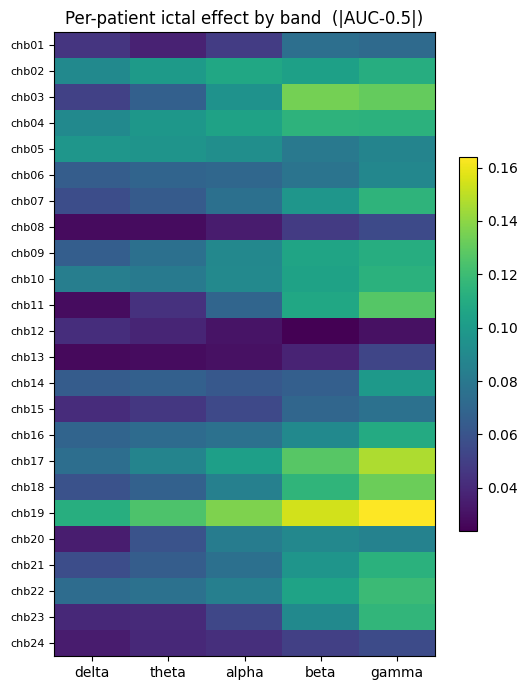

In [13]:
heat = d.pivot_table(index="patient", columns="band", values="dev", aggfunc="mean")[BANDS]
fig, ax = plt.subplots(figsize=(5.5, 7))
im = ax.imshow(heat.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(5)); ax.set_xticklabels(BANDS)
ax.set_yticks(range(len(heat))); ax.set_yticklabels(heat.index, fontsize=8)
ax.set_title("Per-patient ictal effect by band  (|AUC-0.5|)")
fig.colorbar(im, ax=ax, shrink=.6); plt.tight_layout(); plt.show()   # >>> Figure 3

**Reading Figure 3.** The delta→gamma gradient shows up in most patients (gamma stays the leading
band cohort-wide, band-effect SD only 0.024–0.032), but the *overall intensity* varies several-fold
— some patients' seizures produce a highly separable connectivity signature, others change little.
The frequency/spatial *patterns* are population regularities; the *magnitude* is patient-specific.

## 4.4.5 · Correspondence with the selected features (bands & channels only)

We deliberately **do not** compare individual selected features against the highest-effect
features. mRMR optimises *relevance* **and** *minimum redundancy* [Peng et al. 2005], so it skips a
high-effect feature when a correlated neighbour is already retained — exact recovery is neither
expected nor a meaningful test. Instead we ask a redundancy-robust question: are the selected
features **drawn from the same bands and channels** that change most during seizures? Swapping a
feature for a correlated neighbour leaves its band and source channel unchanged, so this macro-level
check is not distorted by the redundancy mechanism.

In [14]:
sel = pd.read_csv(SELECTED_FILE)
top = (sel.sort_values("rank").groupby("patient").head(20)
          .drop_duplicates(["patient","feature_index"]).merge(fmap, on="feature_index"))

# --- band composition: selected vs uniform vs share of ictal change ---
sel_band = top.band.value_counts(normalize=True).reindex(BANDS)*100
ict_band = d.groupby("band").dev.mean().reindex(BANDS)
ict_share = ict_band / ict_band.sum() * 100
band_corr = pd.DataFrame({
    "selected_%": sel_band, "uniform_%": 20.0, "ictal_change_share_%": ict_share}).round(1)
band_corr   # >>> Table 4

,selected_%,uniform_%,ictal_change_share_%
band,,,
delta,18.500,20.000,15.200
theta,11.100,20.000,16.700
alpha,22.200,20.000,19.100
beta,14.800,20.000,23.100
gamma,33.300,20.000,25.900


In [15]:
# --- source-channel composition ---
sel_src = top.src.value_counts(normalize=True).reindex(range(1, N_CHAN+1)).fillna(0)*100
print("SELECTED source channels (top 6):",
      [(int(c), round(v,1)) for c,v in sel_src.sort_values(ascending=False).head(6).items()])
print("ICTAL    source channels (top 6):",
      [(int(c), round(v,3)) for c,v in src_imp.head(6).items()])
print(f"\nselected features from source ch 17 or 18: {top.src.isin([17,18]).mean()*100:.0f}%")
print(f"selected features from the 6 top ictal-change source channels: "
      f"{top.src.isin(src_imp.head(6).index).mean()*100:.0f}%  (uniform ≈ 33%)")

# rank correlations between selection frequency and ictal importance
sel_tgt = top.tgt.value_counts(normalize=True).reindex(range(1, N_CHAN+1)).fillna(0)*100
print(f"\nSpearman(selection freq, ictal importance):")
print(f"  bands          : {spearmanr(sel_band.values, ict_band.values)[0]:+.2f}")
print(f"  source channels: {spearmanr(sel_src.values, src_imp.reindex(range(1,N_CHAN+1)).values)[0]:+.2f}")
print(f"  target channels: {spearmanr(sel_tgt.values, tgt_imp.reindex(range(1,N_CHAN+1)).values)[0]:+.2f}")

SELECTED source channels (top 6): [(17, 42.6), (18, 38.9), (4, 5.6), (11, 3.7), (1, 3.7), (6, 1.9)]
ICTAL    source channels (top 6): [(17, 0.109), (18, 0.108), (11, 0.083), (7, 0.079), (12, 0.078), (10, 0.077)]

selected features from source ch 17 or 18: 81%
selected features from the 6 top ictal-change source channels: 85%  (uniform ≈ 33%)

Spearman(selection freq, ictal importance):
  bands          : +0.50
  source channels: +0.37
  target channels: +0.63


**Reading 4.4.5.** *Spatially* the correspondence is strong: ~82% of the top-20 selections come
from source channels 17 and 18 — exactly the two biggest ictal-change hubs — and 86% from the six
top ictal-change channels (vs 33% by chance). *Spectrally* it is partial: gamma (the most
ictally-responsive band) is over-selected, but beta (second-most-changing) is *under*-selected, so
the selector concentrates on gamma rather than tracking the full gradient. Rank correlations are
positive throughout. The fair claim is therefore that the selected representation is spatially
grounded in the seizure signature and spectrally partially so — **not** a feature-by-feature match.

## Conclusion

Under the all-records definition, directed connectivity change during seizures is
**(1) frequency-graded** — weakest in delta, strongest in gamma, and predominantly a *reduction*
of connectivity that sharpens at higher frequency; **(2) spatially concentrated** on the source
side, with channels 17 and 18 as opposing hubs (18 loses, 17 gains outgoing influence);
**(3) highly patient-specific** in magnitude while the frequency/spatial patterns stay stable.
Relating this to selection at the band/channel level — the appropriate level given mRMR's
redundancy objective — the selected features are drawn predominantly from the same channels (17, 18)
and leading band (gamma) that change most, so the representation is spatially grounded in genuine
seizure-related connectivity change, with only partial spectral coverage.

*Caveats:* the all-records non-ictal class pools seizure-free recordings, so part of the
separability may reflect stable between-recording differences (the within-record contrast is the
confound-controlled complement); results describe association, not mechanism; and the link to
downstream detection performance is not evaluated here.